# Un RNN caractère par caractère avec PyTorch (Tiny Shakespeare)

Objectif : entraîner un **modèle de langage au niveau des caractères**. Étant donné une suite de caractères, le réseau prédit le caractère suivant. Une fois entraîné, on peut lui faire générer du texte « à la Shakespeare », caractère par caractère.

On écrit le RNN « vanille » à la main, avec une boucle explicite sur le temps, comme dans le cours CS231n, puis on le compare à `nn.RNN` de PyTorch.

Étapes : texte → vocabulaire → batchs → modèle → entraînement → courbes → génération → comparaison avec `nn.RNN`.

## 1. Imports, device et seeds

Comme pour le CNN : on choisit `cuda`, puis `mps`, sinon `cpu`, et on fixe les graines aléatoires pour pouvoir reproduire les résultats.

In [2]:
import math
import os
import random
import time
import urllib.request

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

# Choix du device : cuda > mps > cpu
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print('Device utilisé :', device)

# Seeds pour la reproductibilité
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED);  # le ; évite d'afficher l'objet Generator renvoyé

Device utilisé : cuda


## 2. Chargement du texte

Tiny Shakespeare est un fichier texte d'environ 1,1 million de caractères qui rassemble des extraits de pièces de Shakespeare. On le télécharge dans `./data/input.txt`, uniquement s'il n'est pas déjà présent.

Si le téléchargement échoue (pas d'accès à Internet, par exemple), la cellule s'arrête avec un message qui explique quoi faire. N'importe quel fichier texte assez long, encodé en UTF-8, fera l'affaire.

Remarque : `data/` est dans le `.gitignore`, donc ce fichier ne sera pas commité.

In [3]:
DATA_PATH = './data/input.txt'
URL = 'https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt'

if not os.path.exists(DATA_PATH):
    os.makedirs(os.path.dirname(DATA_PATH), exist_ok=True)
    try:
        print('Téléchargement de Tiny Shakespeare...')
        urllib.request.urlretrieve(URL, DATA_PATH)
    except Exception as e:
        if os.path.exists(DATA_PATH):
            os.remove(DATA_PATH)  # on retire un éventuel fichier partiellement téléchargé
        raise RuntimeError(
            f'Le téléchargement a échoué ({e}).\n'
            f'Place toi-même un fichier texte (UTF-8) à cet endroit : {os.path.abspath(DATA_PATH)}\n'
            'puis relance cette cellule.'
        ) from None

with open(DATA_PATH, encoding='utf-8') as f:
    text = f.read()

print('Nombre de caractères :', len(text))
print('-' * 40)
print(text[:300])

Téléchargement de Tiny Shakespeare...
Nombre de caractères : 1115394
----------------------------------------
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us


## 3. Vocabulaire, encodage et séparation train / validation

Un réseau de neurones ne manipule que des nombres. On associe donc à chaque caractère distinct du texte un indice entier :
- `stoi` (*string to index*) : caractère → indice ;
- `itos` (*index to string*) : indice → caractère ;
- `encode` transforme une chaîne en liste d'indices, et `decode` fait l'inverse.

On sépare ensuite le texte en **90 % pour le train** (le début) et **10 % pour la validation** (la fin). La séparation est **contiguë**, sans mélange : si on mélangeait des morceaux, des fenêtres de validation chevaucheraient presque le texte d'entraînement, et la validation serait trop optimiste.

In [4]:
chars = sorted(set(text))   # liste triée des caractères distincts
vocab_size = len(chars)

stoi = {ch: i for i, ch in enumerate(chars)}   # caractère -> indice
itos = {i: ch for i, ch in enumerate(chars)}   # indice -> caractère

def encode(s):
    return [stoi[c] for c in s]

def decode(indices):
    return ''.join(itos[i] for i in indices)

print('Taille du vocabulaire :', vocab_size)
print('Caractères :', repr(''.join(chars)))
print('Exemple :', repr(text[:20]), '->', encode(text[:20]))
assert decode(encode(text[:1000])) == text[:1000]   # encode puis decode redonne le texte d'origine

# Tout le texte sous forme d'un tenseur 1D d'entiers
data = torch.tensor(encode(text), dtype=torch.long)   # (nombre de caractères,)

# Séparation contiguë : début = train, fin = validation
n_train = int(0.9 * len(data))
train_data = data[:n_train]
val_data = data[n_train:]
print('Train :', len(train_data), 'caractères | Validation :', len(val_data), 'caractères')

Taille du vocabulaire : 65
Caractères : "\n !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz"
Exemple : 'First Citizen:\nBefor' -> [18, 47, 56, 57, 58, 1, 15, 47, 58, 47, 64, 43, 52, 10, 0, 14, 43, 44, 53, 56]
Train : 1003854 caractères | Validation : 111540 caractères


## 4. Construction des batchs

`get_batch` tire au hasard `BATCH_SIZE = 64` positions de départ dans le texte, puis découpe à partir de chacune une fenêtre de `SEQ_LEN = 100` caractères.
- `x` contient les caractères aux positions t, t+1, ..., t+99 ;
- `y` contient les mêmes fenêtres **décalées d'un caractère** : t+1, ..., t+100.

À chaque position, la cible `y[b, i]` est donc le caractère qui suit `x[b, i]`. Une seule fenêtre fournit ainsi 100 exemples d'apprentissage.

In [5]:
BATCH_SIZE = 64
SEQ_LEN = 100

def get_batch(split):
    data_split = train_data if split == 'train' else val_data
    # Positions de départ aléatoires ; on s'arrête assez tôt pour que y (décalé de 1) tienne dans le texte
    starts = torch.randint(len(data_split) - SEQ_LEN, (BATCH_SIZE,))
    x = torch.stack([data_split[i:i + SEQ_LEN] for i in starts])           # (BATCH_SIZE, SEQ_LEN)
    y = torch.stack([data_split[i + 1:i + SEQ_LEN + 1] for i in starts])   # (BATCH_SIZE, SEQ_LEN)
    return x.to(device), y.to(device)

xb, yb = get_batch('train')
print('x :', tuple(xb.shape), '| y :', tuple(yb.shape))
print('x[0] (début) :', repr(decode(xb[0, :40].tolist())))
print('y[0] (début) :', repr(decode(yb[0, :40].tolist())))   # même texte, décalé d'un caractère

x : (64, 100) | y : (64, 100)
x[0] (début) : 'illars that will stand to us;\nAnd, if we'
y[0] (début) : 'llars that will stand to us;\nAnd, if we '


## 5. Le RNN « vanille », écrit à la main

À chaque pas de temps t, le RNN lit un caractère et met à jour son **état caché** $h_t$, un vecteur de taille 128 qui résume ce qu'il a lu jusque-là :

$$h_t = \tanh(W_{xh} x_t + W_{hh} h_{t-1} + b_h) \qquad y_t = W_{hy} h_t + b_y$$

- $x_t$ est le vecteur d'**embedding** du caractère t. `nn.Embedding` est simplement une table apprise qui associe à chaque indice un vecteur, ce qui revient à multiplier un vecteur one-hot par une matrice.
- **Les mêmes poids** $W_{xh}$, $W_{hh}$ et $W_{hy}$ servent à tous les pas de temps : c'est ce qui rend le réseau récurrent.
- $y_t$ contient les **logits** : un score par caractère du vocabulaire pour prédire le caractère suivant.

On utilise `nn.Linear` pour les produits matriciels : `nn.Linear(a, b)(v)` calcule `v @ W.T + b`. $b_h$ est le biais de `W_hh`, et $W_{xh}$ n'a pas de biais (un seul suffit).

Le `forward` accepte un état initial `h` optionnel (des zéros par défaut) et renvoie aussi le dernier état. On s'en servira à la génération pour continuer la séquence là où on s'est arrêté.

In [6]:
EMBED_SIZE = 64
HIDDEN_SIZE = 128

class CharRNN(nn.Module):
    def __init__(self, vocab_size, embed_size=EMBED_SIZE, hidden_size=HIDDEN_SIZE):
        super().__init__()
        self.hidden_size = hidden_size
        self.embed = nn.Embedding(vocab_size, embed_size)              # indice -> vecteur de taille E
        self.W_xh = nn.Linear(embed_size, hidden_size, bias=False)     # entrée -> caché
        self.W_hh = nn.Linear(hidden_size, hidden_size)                # caché -> caché (son biais = b_h)
        self.W_hy = nn.Linear(hidden_size, vocab_size)                 # caché -> logits (son biais = b_y)

    def forward(self, x, h=None):
        # x : (B, T) indices de caractères ; h : (B, H) état caché initial, ou None
        B, T = x.shape
        if h is None:
            h = torch.zeros(B, self.hidden_size, device=x.device)     # (B, H)
        emb = self.embed(x)                                            # (B, T, E)

        hs = []
        for t in range(T):                                             # boucle explicite sur le temps
            x_t = emb[:, t, :]                                         # (B, E)
            h = torch.tanh(self.W_xh(x_t) + self.W_hh(h))              # (B, H)  h_t = tanh(W_xh x_t + W_hh h_{t-1} + b_h)
            hs.append(h)
        hs = torch.stack(hs, dim=1)                                    # (B, T, H)  tous les états cachés

        logits = self.W_hy(hs)                                         # (B, T, V)  y_t = W_hy h_t + b_y, pour tous les t d'un coup
        return logits, h                                               # h : (B, H) dernier état caché


model = CharRNN(vocab_size).to(device)
print(model)
print(f'Nombre de paramètres : {sum(p.numel() for p in model.parameters()):,}')

# Vérification des formes sur le batch de la section 4
with torch.no_grad():
    logits, h = model(xb)
print('logits :', tuple(logits.shape), '| dernier h :', tuple(h.shape))

CharRNN(
  (embed): Embedding(65, 64)
  (W_xh): Linear(in_features=64, out_features=128, bias=False)
  (W_hh): Linear(in_features=128, out_features=128, bias=True)
  (W_hy): Linear(in_features=128, out_features=65, bias=True)
)
Nombre de paramètres : 37,249
logits : (64, 100, 65) | dernier h : (64, 128)


## 6. Entraînement

- **Perte** : `CrossEntropyLoss` sur **tous les pas de temps**. On aplatit les logits `(B, T, V)` en `(B*T, V)` et les cibles `(B, T)` en `(B*T,)` : chaque position est un problème de classification à V classes, et la perte est la moyenne sur les B×T positions.
- **Optimiseur** : Adam, lr = 2e-3.
- **Gradient clipping** : dans un RNN, le gradient traverse 100 fois la même matrice $W_{hh}$ pendant la rétropropagation dans le temps, et il peut **exploser**. `clip_grad_norm_` remet la norme globale du gradient à 5 quand elle dépasse cette valeur. La fonction renvoie la norme **avant** clipping, qu'on affiche pour voir quand le clipping intervient.
- **Évaluation** : toutes les 200 itérations, `estimate_loss` calcule la loss moyenne sur 20 batchs de train et 20 batchs de validation, sous `torch.no_grad()` et `model.eval()`. C'est plus fiable que la loss bruitée d'un seul batch.
- **Perplexité** : $\exp(\text{loss})$, à lire comme « le modèle hésite en moyenne entre autant de caractères ». Un modèle qui répond au hasard a une loss de $\ln(V)$ et une perplexité de V.

Chaque batch repart d'un état caché nul : le modèle apprend donc à partir de contextes d'au plus 100 caractères.

La boucle est écrite dans une fonction `train` pour pouvoir la réutiliser telle quelle avec le modèle `nn.RNN` à la section 9.

In [7]:
MAX_ITERS = 3000
EVAL_INTERVAL = 200
EVAL_BATCHES = 20
LR = 2e-3
MAX_NORM = 5.0

criterion = nn.CrossEntropyLoss()


def compute_loss(model, x, y):
    logits, _ = model(x)                                                     # (B, T, V)
    return criterion(logits.reshape(-1, vocab_size), y.reshape(-1))         # (B*T, V) contre (B*T,)


@torch.no_grad()
def estimate_loss(model):
    model.eval()
    out = {}
    for split in ['train', 'val']:
        losses = [compute_loss(model, *get_batch(split)).item() for _ in range(EVAL_BATCHES)]
        out[split] = sum(losses) / len(losses)
    model.train()
    return out


def train(model, max_iters=MAX_ITERS):
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    iters, train_losses, val_losses = [], [], []
    model.train()
    start = time.time()
    for it in range(1, max_iters + 1):
        x, y = get_batch('train')
        loss = compute_loss(model, x, y)

        optimizer.zero_grad()
        loss.backward()
        grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=MAX_NORM)  # norme AVANT clipping
        optimizer.step()

        if it % EVAL_INTERVAL == 0 or it == max_iters:
            losses = estimate_loss(model)
            iters.append(it)
            train_losses.append(losses['train'])
            val_losses.append(losses['val'])
            print(f'iter {it:4d} | '
                  f'train loss {losses["train"]:.4f} (ppl {math.exp(losses["train"]):5.2f}) | '
                  f'val loss {losses["val"]:.4f} (ppl {math.exp(losses["val"]):5.2f}) | '
                  f'grad norm {grad_norm.item():.2f}')
    train_time = time.time() - start
    print(f'Durée d\'entraînement : {train_time:.1f} s')
    return iters, train_losses, val_losses, train_time


# Loss avant entraînement : elle doit être proche de ln(V), celle d'une prédiction uniforme
init = estimate_loss(model)
print(f'Avant entraînement : val loss {init["val"]:.4f} | ln(vocab_size) = {math.log(vocab_size):.4f}')

iters, train_losses, val_losses, train_time = train(model)

Avant entraînement : val loss 4.1823 | ln(vocab_size) = 4.1744
iter  200 | train loss 1.9889 (ppl  7.31) | val loss 2.0363 (ppl  7.66) | grad norm 0.16
iter  400 | train loss 1.8062 (ppl  6.09) | val loss 1.8954 (ppl  6.65) | grad norm 0.20
iter  600 | train loss 1.7269 (ppl  5.62) | val loss 1.8512 (ppl  6.37) | grad norm 0.20
iter  800 | train loss 1.6636 (ppl  5.28) | val loss 1.8117 (ppl  6.12) | grad norm 0.21
iter 1000 | train loss 1.6349 (ppl  5.13) | val loss 1.7923 (ppl  6.00) | grad norm 0.22
iter 1200 | train loss 1.6113 (ppl  5.01) | val loss 1.7766 (ppl  5.91) | grad norm 0.21
iter 1400 | train loss 1.5949 (ppl  4.93) | val loss 1.7514 (ppl  5.76) | grad norm 0.23
iter 1600 | train loss 1.5859 (ppl  4.88) | val loss 1.7556 (ppl  5.79) | grad norm 0.23
iter 1800 | train loss 1.5657 (ppl  4.79) | val loss 1.7413 (ppl  5.70) | grad norm 0.23
iter 2000 | train loss 1.5627 (ppl  4.77) | val loss 1.7372 (ppl  5.68) | grad norm 0.23
iter 2200 | train loss 1.5366 (ppl  4.65) | val

## 7. Courbes de loss

La ligne pointillée grise indique la loss d'un modèle qui prédit au hasard ($\ln V$). Avec environ 37 000 paramètres pour 1 million de caractères, le modèle est petit : on s'attend à un écart faible entre train et validation, donc peu de sur-apprentissage.

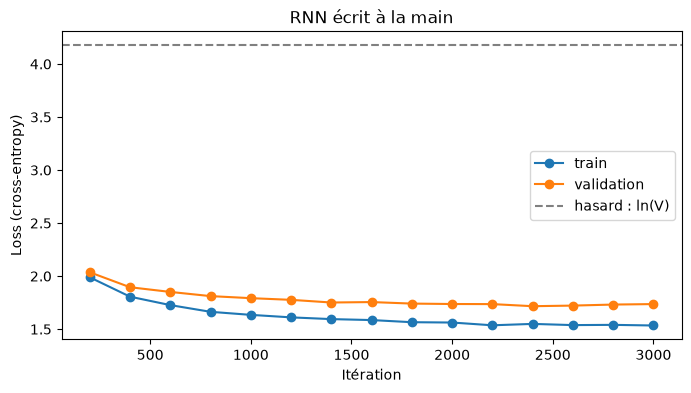

In [8]:
plt.figure(figsize=(8, 4))
plt.plot(iters, train_losses, marker='o', label='train')
plt.plot(iters, val_losses, marker='o', label='validation')
plt.axhline(math.log(vocab_size), color='gray', linestyle='--', label='hasard : ln(V)')
plt.xlabel('Itération')
plt.ylabel('Loss (cross-entropy)')
plt.title('RNN écrit à la main')
plt.legend()
plt.show()

## 8. Génération de texte

On part d'un début de texte (`start_str`) :
1. On le fait passer dans le RNN pour obtenir l'état caché et les logits du caractère suivant.
2. On transforme les logits en probabilités avec `softmax(logits / temperature)`, puis on **tire au hasard** un caractère avec `torch.multinomial`.
3. On redonne ce caractère au RNN **avec l'état caché courant**, et on recommence.

La **température** règle l'audace du modèle :
- **petite (0.5)** : la distribution est plus piquée, le texte plus sûr et plus « correct », mais aussi plus répétitif ;
- **1.0** : on échantillonne la distribution apprise telle quelle, avec plus de variété et plus de mots inventés.

In [9]:
@torch.no_grad()
def sample(model, start_str, length, temperature=1.0):
    model.eval()
    x = torch.tensor([encode(start_str)], device=device)           # (1, len(start_str))
    logits, h = model(x)                                            # on lit le début ; h : (1, H)
    out = start_str
    for _ in range(length):
        last_logits = logits[:, -1, :] / temperature                # (1, V) logits du dernier pas de temps
        probs = torch.softmax(last_logits, dim=-1)                  # (1, V) probabilités
        idx = torch.multinomial(probs, num_samples=1)               # (1, 1) caractère tiré au hasard
        out += itos[idx.item()]
        logits, h = model(idx, h)                                   # un pas de plus, en gardant l'état caché
    model.train()
    return out


START = 'ROMEO:'
for temperature in [0.5, 1.0]:
    torch.manual_seed(SEED)   # même graine pour les deux températures
    print(f'===== temperature = {temperature} =====')
    print(sample(model, START, length=500, temperature=temperature))
    print()

===== temperature = 0.5 =====
ROMEO:
The seath battle than that do than you be your heart the one and lape is comes have not the true than your his come the man to have stand are say the rest that we shall not shall he shall be thought and will we are as the changed me than my faming said will be not, my lords, and the man and down so thou thanks and not speak persue to my son, and the will have he cannot than the see the world than say may do sing and some hand,
My will my son, but we come, consuard have he shall be stay provide 

===== temperature = 1.0 =====
ROMEO:
Father; nob this we day.

LADY ANNE:
Well: Tranio,
It me, and be laption but I have good
state.
Why, if indeed
What lateman, you'll storl,
The and courly and promem, chance you.
No, indeed by horse.

PARIS:
No:
Hark son, and this methinks me here in her lass of thou know destrust
Marmil an your seam, of that.

ELLONCUS:
O, Richmond;
Let son,
And lung.

COMINIUS:
If in thing he
postion all the duke a denion,
But, God:
Keep

## 9. Comparaison avec `nn.RNN` de PyTorch

On garde le même modèle (embedding de taille 64, état caché de taille 128, couche de sortie), mais la boucle sur le temps est remplacée par `nn.RNN`, qui calcule exactement la même récurrence tanh. Seule petite différence : `nn.RNN` a deux biais (`b_ih` et `b_hh`) au lieu d'un, soit 128 paramètres de plus.

On réutilise la fonction `train` de la section 6, avec les mêmes hyperparamètres. Sur GPU, `nn.RNN` passe par un noyau cuDNN optimisé, alors que notre boucle Python lance plusieurs petites opérations par pas de temps : on s'attend à ce qu'elle soit nettement plus lente, pour une loss similaire.

In [10]:
class TorchCharRNN(nn.Module):
    def __init__(self, vocab_size, embed_size=EMBED_SIZE, hidden_size=HIDDEN_SIZE):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_size)
        self.rnn = nn.RNN(embed_size, hidden_size, nonlinearity='tanh', batch_first=True)
        self.W_hy = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, h=None):
        emb = self.embed(x)                                        # (B, T, E)
        h0 = None if h is None else h.unsqueeze(0)                 # nn.RNN attend un état de forme (num_layers=1, B, H)
        hs, h_last = self.rnn(emb, h0)                             # hs : (B, T, H), h_last : (1, B, H)
        return self.W_hy(hs), h_last.squeeze(0)                   # (B, T, V), (B, H)


torch.manual_seed(SEED)
model_torch = TorchCharRNN(vocab_size).to(device)
print(f'Nombre de paramètres : {sum(p.numel() for p in model_torch.parameters()):,}')
_, _, val_losses_torch, train_time_torch = train(model_torch)

print()
print(f'{"":12s} | {"val loss finale":>15s} | {"temps (s)":>9s}')
print(f'{"à la main":12s} | {val_losses[-1]:15.4f} | {train_time:9.1f}')
print(f'{"nn.RNN":12s} | {val_losses_torch[-1]:15.4f} | {train_time_torch:9.1f}')
print(f'nn.RNN est {train_time / train_time_torch:.1f}x plus rapide')

Nombre de paramètres : 37,377
iter  200 | train loss 1.9938 (ppl  7.34) | val loss 2.0263 (ppl  7.59) | grad norm 0.16
iter  400 | train loss 1.8101 (ppl  6.11) | val loss 1.9041 (ppl  6.71) | grad norm 0.19
iter  600 | train loss 1.7175 (ppl  5.57) | val loss 1.8507 (ppl  6.36) | grad norm 0.21
iter  800 | train loss 1.6680 (ppl  5.30) | val loss 1.8172 (ppl  6.15) | grad norm 0.22
iter 1000 | train loss 1.6359 (ppl  5.13) | val loss 1.7921 (ppl  6.00) | grad norm 0.23
iter 1200 | train loss 1.6143 (ppl  5.02) | val loss 1.7532 (ppl  5.77) | grad norm 0.23
iter 1400 | train loss 1.6060 (ppl  4.98) | val loss 1.7615 (ppl  5.82) | grad norm 0.25
iter 1600 | train loss 1.5837 (ppl  4.87) | val loss 1.7473 (ppl  5.74) | grad norm 0.26
iter 1800 | train loss 1.5725 (ppl  4.82) | val loss 1.7518 (ppl  5.77) | grad norm 0.23
iter 2000 | train loss 1.5635 (ppl  4.78) | val loss 1.7324 (ppl  5.65) | grad norm 0.24
iter 2200 | train loss 1.5570 (ppl  4.74) | val loss 1.7169 (ppl  5.57) | grad n